In [ ]:
# Cell 1: Mount Google Drive
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [ ]:
#setting base directory
import os
BASEDIR = '/content/drive/MyDrive/ForestFireDataset/'
print("BASEDIR:", BASEDIR)
print("Contents:", os.listdir(BASEDIR))

BASEDIR: /content/drive/MyDrive/ForestFireDataset/
Contents: ['train']


In [ ]:
# setting dataset paths and splits
import glob
import pandas as pd
from sklearn.model_selection import train_test_split

all_image_paths = []
all_labels = []

for class_name in ['fire', 'nofire']:
    class_dir = os.path.join(BASEDIR, 'train', class_name)
    for ext in ['*.png', '*.jpg', '*.jpeg']:
        paths = glob.glob(os.path.join(class_dir, ext))
        all_image_paths.extend(paths)
        all_labels.extend([class_name] * len(paths))

df = pd.DataFrame({'path': all_image_paths, 'label': all_labels})
df_train, df_temp = train_test_split(df, test_size=0.2, random_state=42, stratify=df['label'])
df_val, df_test = train_test_split(df_temp, test_size=0.5, random_state=42, stratify=df_temp['label'])

print(f"Train: {len(df_train)}, Val: {len(df_val)}, Test: {len(df_test)}")

Train: 2341, Val: 293, Test: 293


In [ ]:
# setting data generators
import tensorflow as tf
from tensorflow.keras.preprocessing.image import ImageDataGenerator

IMAGESIZE = (256, 256)
BATCHSIZE = 32

datagen = ImageDataGenerator(rescale=1./255)

traingen = datagen.flow_from_dataframe(
    df_train,
    directory=BASEDIR,
    x_col='path',
    y_col='label',
    target_size=IMAGESIZE,
    batch_size=BATCHSIZE,
    class_mode='categorical',
    shuffle=True
)

valgen = datagen.flow_from_dataframe(
    df_val,
    directory=BASEDIR,
    x_col='path',
    y_col='label',
    target_size=IMAGESIZE,
    batch_size=BATCHSIZE,
    class_mode='categorical',
    shuffle=False
)

Found 2341 validated image filenames belonging to 2 classes.
Found 293 validated image filenames belonging to 2 classes.


In [ ]:
# Model 1 - MHCNNFD (exact paper architecture)
def build_mhcnnfd_model(input_shape=(256, 256, 3), num_classes=2):
    inputs = tf.keras.Input(shape=input_shape)

    x = tf.keras.layers.Conv2D(32, (3, 3), padding='valid', activation='relu')(inputs)
    x = tf.keras.layers.MaxPooling2D((2, 2))(x)

    x = tf.keras.layers.Conv2D(48, (3, 3), padding='valid', activation='relu')(x)
    x = tf.keras.layers.MaxPooling2D((2, 2))(x)

    x = tf.keras.layers.Conv2D(56, (3, 3), padding='valid', activation='relu')(x)
    x = tf.keras.layers.MaxPooling2D((2, 2))(x)

    x = tf.keras.layers.Conv2D(64, (3, 3), padding='valid', activation='relu')(x)
    x = tf.keras.layers.Dropout(0.1)(x)

    x = tf.keras.layers.Conv2D(32, (3, 3), padding='valid', activation='relu')(x)

    x = tf.keras.layers.GlobalAveragePooling2D()(x)
    x = tf.keras.layers.Dense(64, activation='selu')(x)
    x = tf.keras.layers.Dense(56, activation='selu')(x)
    x = tf.keras.layers.Dense(32, activation='selu')(x)
    outputs = tf.keras.layers.Dense(num_classes, activation='softmax')(x)

    return tf.keras.Model(inputs, outputs)

model = build_mhcnnfd_model()
model.compile(optimizer='adam', loss='categorical_crossentropy', metrics=['accuracy'])
model.summary()


Model: "functional"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer (InputLayer)        │ (None, 256, 256, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d (Conv2D)                 │ (None, 254, 254, 32)   │           896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d (MaxPooling2D)    │ (None, 127, 127, 32)   │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_1 (Conv2D)               │ (None, 125, 125, 48)   │        13,872 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_1 (MaxPooling2D)  │ (None, 62, 62, 48)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_2 (Conv2D)               │ (None, 60, 60, 56)     │        24,248 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_2 (MaxPooling2D)  │ (None, 30, 30, 56)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_3 (Conv2D)               │ (None, 28, 28, 64)     │        32,320 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 28, 28, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_4 (Conv2D)               │ (None, 26, 26, 32)     │        18,464 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_average_pooling2d        │ (None, 32)             │             0 │
│ (GlobalAveragePooling2D)        │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 64)             │         2,112 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 56)             │         3,640 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 32)             │         1,824 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_3 (Dense)                 │ (None, 2)              │            66 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 97,442 (380.63 KB)

 Trainable params: 97,442 (380.63 KB)

 Non-trainable params: 0 (0.00 B)

In [ ]:
# Training with paper's LR schedule
def lr_scheduler(epoch):
    if epoch < 15: return 1e-3
    elif epoch < 31: return 1e-4
    else: return 1e-5

history = model.fit(
    traingen,
    validation_data=valgen,
    epochs=40,
    callbacks=[tf.keras.callbacks.LearningRateScheduler(lr_scheduler)]
)

/usr/local/lib/python3.12/dist-packages/keras/src/trainers/data_adapters/py_dataset_adapter.py:121: UserWarning: Your `PyDataset` class should call `super().__init__(**kwargs)` in its constructor. `**kwargs` can include `workers`, `use_multiprocessing`, `max_queue_size`. Do not pass these arguments to `fit()`, as they will be ignored.
  self._warn_if_super_not_called()


Epoch 1/40
74/74 ━━━━━━━━━━━━━━━━━━━━ 1106s 15s/step - accuracy: 0.8261 - loss: 0.4118 - val_accuracy: 0.9078 - val_loss: 0.2543 - learning_rate: 0.0010
Epoch 2/40
74/74 ━━━━━━━━━━━━━━━━━━━━ 41s 565ms/step - accuracy: 0.8902 - loss: 0.3063 - val_accuracy: 0.9215 - val_loss: 0.2306 - learning_rate: 0.0010
Epoch 3/40
74/74 ━━━━━━━━━━━━━━━━━━━━ 42s 565ms/step - accuracy: 0.9043 - loss: 0.2493 - val_accuracy: 0.9317 - val_loss: 0.2056 - learning_rate: 0.0010
Epoch 4/40
74/74 ━━━━━━━━━━━━━━━━━━━━ 42s 569ms/step - accuracy: 0.9178 - loss: 0.2476 - val_accuracy: 0.9454 - val_loss: 0.2852 - learning_rate: 0.0010
Epoch 5/40
74/74 ━━━━━━━━━━━━━━━━━━━━ 41s 551ms/step - accuracy: 0.9291 - loss: 0.2380 - val_accuracy: 0.9522 - val_loss: 0.1717 - learning_rate: 0.0010
Epoch 6/40
74/74 ━━━━━━━━━━━━━━━━━━━━ 41s 549ms/step - accuracy: 0.9502 - loss: 0.1615 - val_accuracy: 0.9454 - val_loss: 0.1613 - learning_rate: 0.0010
Epoch 7/40
74/74 ━━━━━━━━━━━━━━━━━━━━ 41s 559ms/step - accuracy: 0.9432 - loss: 0.

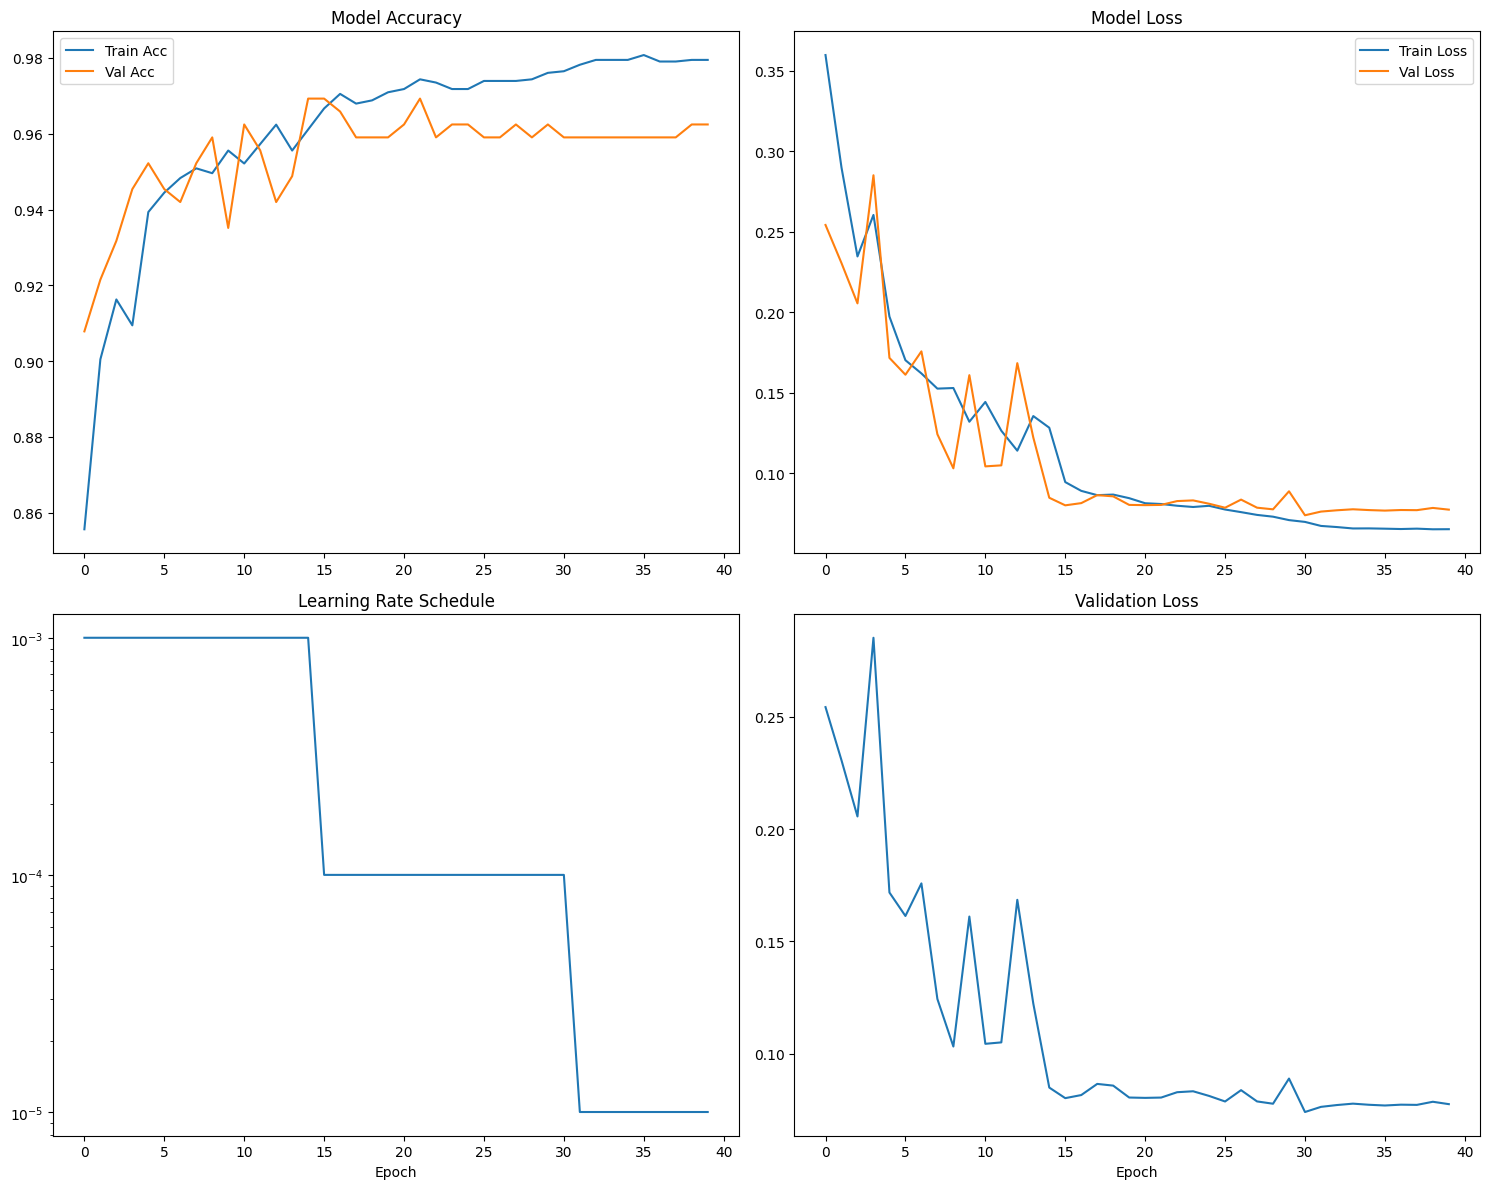

In [ ]:
# Complete Model Analysis
import matplotlib.pyplot as plt
import numpy as np
from sklearn.metrics import confusion_matrix, classification_report, ConfusionMatrixDisplay
import seaborn as sns

# 1. Training History Plots
fig, axes = plt.subplots(2, 2, figsize=(15, 12))

# Accuracy
axes[0,0].plot(history.history['accuracy'], label='Train Acc')
axes[0,0].plot(history.history['val_accuracy'], label='Val Acc')
axes[0,0].set_title('Model Accuracy')
axes[0,0].legend()

# Loss
axes[0,1].plot(history.history['loss'], label='Train Loss')
axes[0,1].plot(history.history['val_loss'], label='Val Loss')
axes[0,1].set_title('Model Loss')
axes[0,1].legend()

# Learning Rate
lr_values = [lr_scheduler(i) for i in range(len(history.history['loss']))]
axes[1,0].plot(lr_values)
axes[1,0].set_title('Learning Rate Schedule')
axes[1,0].set_yscale('log')
axes[1,0].set_xlabel('Epoch')

# Val Loss vs Epochs
axes[1,1].plot(history.history['val_loss'])
axes[1,1].set_title('Validation Loss')
axes[1,1].set_xlabel('Epoch')
plt.tight_layout()
plt.show()


In [ ]:
# 2. Test Evaluation
testgen = datagen.flow_from_dataframe(
    df_test,
    directory=BASEDIR,
    x_col='path',
    y_col='label',
    target_size=IMAGESIZE,
    batch_size=BATCHSIZE,
    class_mode='categorical',
    shuffle=False
)

test_loss, test_acc = model.evaluate(testgen)
print(f"Test Accuracy: {test_acc:.4f}")
print(f"Test Loss: {test_loss:.4f}")


Found 293 validated image filenames belonging to 2 classes.


/usr/local/lib/python3.12/dist-packages/keras/src/trainers/data_adapters/py_dataset_adapter.py:121: UserWarning: Your `PyDataset` class should call `super().__init__(**kwargs)` in its constructor. `**kwargs` can include `workers`, `use_multiprocessing`, `max_queue_size`. Do not pass these arguments to `fit()`, as they will be ignored.
  self._warn_if_super_not_called()


10/10 ━━━━━━━━━━━━━━━━━━━━ 102s 11s/step - accuracy: 0.9678 - loss: 0.1217
Test Accuracy: 0.9625
Test Loss: 0.1318


10/10 ━━━━━━━━━━━━━━━━━━━━ 11s 859ms/step


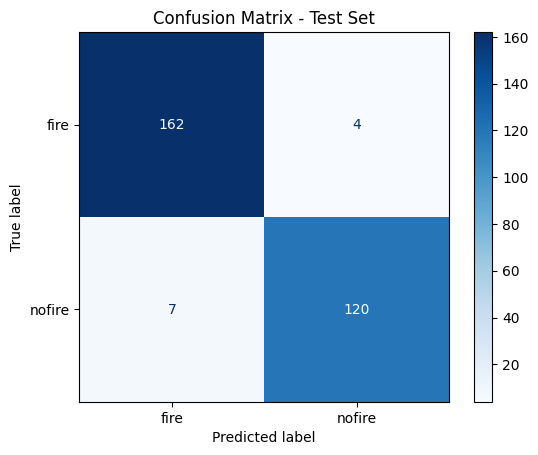


Classification Report:
              precision    recall  f1-score   support

        fire       0.96      0.98      0.97       166
      nofire       0.97      0.94      0.96       127

    accuracy                           0.96       293
   macro avg       0.96      0.96      0.96       293
weighted avg       0.96      0.96      0.96       293



In [ ]:
# 3. Confusion Matrix & Classification Report
y_pred = model.predict(testgen)
y_pred_classes = np.argmax(y_pred, axis=1)
y_true = testgen.classes

# Confusion Matrix
cm = confusion_matrix(y_true, y_pred_classes)
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=testgen.class_indices.keys())
disp.plot(cmap=plt.cm.Blues)
plt.title('Confusion Matrix - Test Set')
plt.show()

# Detailed Classification Report
print("\nClassification Report:")
print(classification_report(y_true, y_pred_classes, target_names=testgen.class_indices.keys()))


In [ ]:
# 4. Per-class Metrics Table
from sklearn.metrics import precision_score, recall_score, f1_score

prec = precision_score(y_true, y_pred_classes, average=None, labels=[0,1])
rec = recall_score(y_true, y_pred_classes, average=None, labels=[0,1])
f1 = f1_score(y_true, y_pred_classes, average=None, labels=[0,1])

metrics_df = pd.DataFrame({
    'Class': ['fire', 'nofire'],
    'Precision': prec,
    'Recall': rec,
    'F1-Score': f1
})
print("\nPer-Class Metrics:")
print(metrics_df.round(4))



Per-Class Metrics:
    Class  Precision  Recall  F1-Score
0    fire     0.9586  0.9759    0.9672
1  nofire     0.9677  0.9449    0.9562


In [ ]:
# 5. Model Save
model.save('/content/drive/MyDrive/mhcnnfd_model1_binary.h5')
print("Model saved successfully!")


Model saved successfully!
